# FCI MTG Zarr quicklook

Open the EUMETSAT Zarr store and plot four timesteps from `data_1km` zarr group of the dataset (see lower down for using a datatree to open whole dataset)

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

In [8]:
endpoint_url = "https://s3.r1.cloud.eumetsat.int"
opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": endpoint_url},
}

prefix = "s3://fci-mtg.level1c.zarr/fci-20250923.zarr/"

# need to specify the group to load the dataset from, otherwise it will try to
# load the entire zarr store as a single dataset, but the two resolution
# datasets are in separate groups, so it will just return an empty dataset.
# I found the group names (channels_at_1km_resolution and
# channels_at_2km_resolution) by listing the bucket contents with `aws s3 ls
# --recursive s3://fci-mtg.level1c.zarr/fci-20250923.zarr/` and looking for the
# group names in the output. The group names are the prefixes of the zarr store
# that contain the datasets.
ds = xr.open_zarr(
    prefix,
    consolidated=True,
    storage_options=opts,
    group="channels_at_1km_resolution",
)
ds

<xarray.Dataset> Size: 834TB
Dimensions:        (channel: 8, time: 52560, y: 11136, x: 11136)
Coordinates:
  * time           (time) datetime64[s] 420kB NaT NaT ... 2025-09-23T23:50:07
  * y              (y) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
  * x              (x) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
    latitude       (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
    longitude      (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
Dimensions without coordinates: channel
Data variables:
    channel_name   (channel) |S16 128B dask.array<chunksize=(8,), meta=np.ndarray>
    counts         (time, y, x, channel) float32 209TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    offset         (time, channel) float64 3MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    pixel_quality  (time, y, x, channel) float32 209TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    pixel_time     (time, y, x, channel) datetime64[ns] 417TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    slope          (time, channel) float64 3MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    spatial_ref    float32 4B ...
Attributes:
    Conventions:  CF-1.8
    title:        MTG FCI Level 1C effective radiances (1km)
    institution:  EUMETSAT
    source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
    history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [9]:
# select by index number rather than value works just fine
# NB: the last time index in the subset is 52560, and only the last 6 time indices are present in the subset
ntime = 52560
nsample = 6
ds_subset = ds.isel(time=slice(ntime-nsample, ntime))
ds_subset

<xarray.Dataset> Size: 96GB
Dimensions:        (channel: 8, time: 6, y: 11136, x: 11136)
Coordinates:
  * time           (time) datetime64[s] 48B 2025-09-23T23:00:07 ... 2025-09-2...
  * y              (y) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
  * x              (x) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
    latitude       (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
    longitude      (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
Dimensions without coordinates: channel
Data variables:
    channel_name   (channel) |S16 128B dask.array<chunksize=(8,), meta=np.ndarray>
    counts         (time, y, x, channel) float32 24GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    offset         (time, channel) float64 384B dask.array<chunksize=(1, 8), meta=np.ndarray>
    pixel_quality  (time, y, x, channel) float32 24GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    pixel_time     (time, y, x, channel) datetime64[ns] 48GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    slope          (time, channel) float64 384B dask.array<chunksize=(1, 8), meta=np.ndarray>
    spatial_ref    float32 4B ...
Attributes:
    Conventions:  CF-1.8
    title:        MTG FCI Level 1C effective radiances (1km)
    institution:  EUMETSAT
    source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
    history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [10]:
# print out the sample coordinate values (select on time first so that we dont have to load all the chunks)
counts = ds_subset["counts"]
channel_names = [name.decode("utf-8") if isinstance(name, (bytes, bytearray)) else str(name) for name in ds_subset["channel_name"].values]
time_values = ds_subset["time"].values

print("counts shape:", counts.shape)
print("channels:", channel_names)
# XXX: all timesteps appear to be NaT?
print("first timestamps:", time_values[:4])

counts shape: (6, 11136, 11136, 8)
channels: ['vis_04', 'vis_05', 'vis_06', 'vis_08', 'vis_09', 'nir_13', 'nir_16', 'nir_22']
first timestamps: ['2025-09-23T23:00:07' '2025-09-23T23:10:07' '2025-09-23T23:20:07'
 '2025-09-23T23:30:07']


In [11]:
# select the very first timestep, the first two channels, and a 500x500 pixel region in the middle of the image. This is a small enough slice that it should be able to be read into memory without issue.
nx = ds.sizes["x"]
ny = ds.sizes["y"]
nsize = 500
xilim = slice(nx//2 - nsize//2, nx//2 + nsize//2)
yilim = slice(ny//2 - nsize//2, ny//2 + nsize//2)
da = ds_subset.sel(time='2025-09-23', method="nearest").isel(channel=slice(0, 2), x=xilim, y=yilim)["counts"]
da

<xarray.DataArray 'counts' (y: 500, x: 500, channel: 2)> Size: 2MB
dask.array<getitem, shape=(500, 500, 2), dtype=float32, chunksize=(258, 500, 1), chunktype=numpy.ndarray>
Coordinates:
  * y          (y) float64 4kB -2.495e+05 -2.485e+05 ... 2.485e+05 2.495e+05
  * x          (x) float64 4kB -2.495e+05 -2.485e+05 ... 2.485e+05 2.495e+05
    latitude   (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    longitude  (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    time       datetime64[s] 8B 2025-09-23T23:00:07
Dimensions without coordinates: channel
Attributes:
    units:                1
    long_name:            FCI raw detector counts
    grid_mapping:         spatial_ref
    ancillary_variables:  pixel_quality pixel_time

In [12]:
# XXX: read is quite slow (>30s) even though only a few chunks should be read?
da = da.load()

[array(200., dtype=float32),
 array(207., dtype=float32),
 array(203.62, dtype=float32)]

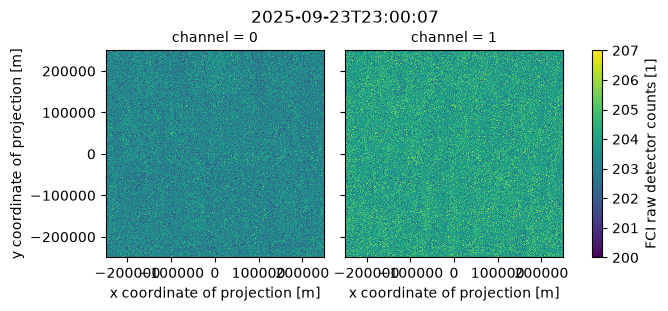

In [13]:
g = da.plot(col="channel")
g.fig.suptitle(da.time.values, y=1.02)
[da_.values for da_ in [da.min(), da.max(), da.mean()]]

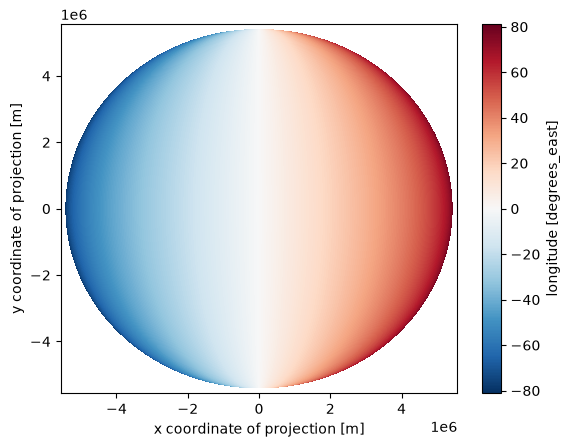

In [14]:
## full-disc view of the Earth visible from the satellite

# longitude and lattitude values are NaN outside of the "full disc" (i.e. where
# the Earth visible from the satellite). The NaN values are not plotted by
# default, so we can use this to visualize the Earth visible from the
# satellite.
da_lons = ds.longitude.load()
da_lons.plot()

## Loading all zarr groups as a datatree

In [16]:
# try loading all zarr groups as a datatree

prefix = "s3://fci-mtg.level1c.zarr/fci-20250923.zarr/"

opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.r1.cloud.eumetsat.int"},
}

# loading works!
dt = xr.open_datatree(
    prefix,
    consolidated=False,
    storage_options=opts,
)
dt

<xarray.DataTree>
Group: /
├── Group: /channels_at_2km_resolution
│       Dimensions:        (channel: 8, time: 52560, y: 5568, x: 5568)
│       Coordinates:
│         * time           (time) datetime64[s] 420kB NaT NaT ... 2025-09-23T23:50:07
│         * y              (y) float64 45kB -5.567e+06 -5.565e+06 ... 5.567e+06
│         * x              (x) float64 45kB -5.567e+06 -5.565e+06 ... 5.567e+06
│           latitude       (y, x) float32 124MB ...
│           longitude      (y, x) float32 124MB ...
│       Dimensions without coordinates: channel
│       Data variables:
│           channel_name   (channel) |S16 128B ...
│           counts         (time, y, x, channel) float32 52TB ...
│           offset         (time, channel) float64 3MB ...
│           pixel_time     (time, y, x, channel) datetime64[ns] 104TB ...
│           slope          (time, channel) float64 3MB ...
│           spatial_ref    float32 4B ...
│           pixel_quality  (time, y, x, channel) float32 52TB ...
│       Attributes:
│           Conventions:  CF-1.8
│           title:        MTG FCI Level 1C effective radiances (2km)
│           institution:  EUMETSAT
│           source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
│           history:      Ingested to Zarr by firecube-mtg-fci-l1c
└── Group: /channels_at_1km_resolution
        Dimensions:        (channel: 8, time: 52560, y: 11136, x: 11136)
        Coordinates:
          * time           (time) datetime64[s] 420kB NaT NaT ... 2025-09-23T23:50:07
          * y              (y) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
          * x              (x) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
            latitude       (y, x) float32 496MB ...
            longitude      (y, x) float32 496MB ...
        Dimensions without coordinates: channel
        Data variables:
            channel_name   (channel) |S16 128B ...
            counts         (time, y, x, channel) float32 209TB ...
            pixel_quality  (time, y, x, channel) float32 209TB ...
            offset         (time, channel) float64 3MB ...
            spatial_ref    float32 4B ...
            slope          (time, channel) float64 3MB ...
            pixel_time     (time, y, x, channel) datetime64[ns] 417TB ...
        Attributes:
            Conventions:  CF-1.8
            title:        MTG FCI Level 1C effective radiances (1km)
            institution:  EUMETSAT
            source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
            history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [17]:
# XXX: xarray doesn't recognise the shared time coordinate across the datasets, so something needs to be changed here to allow for that
dt.coords

Coordinates:
    *empty*

In [18]:
GROUPS = ["channels_at_1km_resolution", "channels_at_2km_resolution"]


def lift_shared_time(dt: xr.DataTree, groups: list[str] = GROUPS) -> xr.DataTree:
    """Move an identical `time` coordinate from each child group up to the root."""
    reference = dt[groups[0]]["time"]
    for name in groups[1:]:
        if not dt[name]["time"].identical(reference):
            raise ValueError(f"time coordinate on '{name}' differs from '{groups[0]}'")

    for name in groups:
        dt[name].dataset = dt[name].dataset.drop_vars("time")

    dt.dataset = dt.dataset.assign_coords(time=reference)
    return dt

In [19]:
dt = lift_shared_time(dt)
dt.attrs["sample_attribute"] = "sample_value"
dt

<xarray.DataTree>
Group: /
│   Dimensions:  (time: 52560)
│   Coordinates:
│     * time     (time) datetime64[s] 420kB NaT NaT ... 2025-09-23T23:50:07
│   Attributes:
│       sample_attribute:  sample_value
├── Group: /channels_at_2km_resolution
│       Dimensions:        (channel: 8, time: 52560, y: 5568, x: 5568)
│       Coordinates:
│         * y              (y) float64 45kB -5.567e+06 -5.565e+06 ... 5.567e+06
│         * x              (x) float64 45kB -5.567e+06 -5.565e+06 ... 5.567e+06
│           latitude       (y, x) float32 124MB ...
│           longitude      (y, x) float32 124MB ...
│       Dimensions without coordinates: channel
│       Data variables:
│           channel_name   (channel) |S16 128B ...
│           counts         (time, y, x, channel) float32 52TB ...
│           offset         (time, channel) float64 3MB ...
│           pixel_time     (time, y, x, channel) datetime64[ns] 104TB ...
│           slope          (time, channel) float64 3MB ...
│           spatial_ref    float32 4B ...
│           pixel_quality  (time, y, x, channel) float32 52TB ...
│       Attributes:
│           Conventions:  CF-1.8
│           title:        MTG FCI Level 1C effective radiances (2km)
│           institution:  EUMETSAT
│           source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
│           history:      Ingested to Zarr by firecube-mtg-fci-l1c
└── Group: /channels_at_1km_resolution
        Dimensions:        (channel: 8, time: 52560, y: 11136, x: 11136)
        Coordinates:
          * y              (y) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
          * x              (x) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
            latitude       (y, x) float32 496MB ...
            longitude      (y, x) float32 496MB ...
        Dimensions without coordinates: channel
        Data variables:
            channel_name   (channel) |S16 128B ...
            counts         (time, y, x, channel) float32 209TB ...
            pixel_quality  (time, y, x, channel) float32 209TB ...
            offset         (time, channel) float64 3MB ...
            spatial_ref    float32 4B ...
            slope          (time, channel) float64 3MB ...
            pixel_time     (time, y, x, channel) datetime64[ns] 417TB ...
        Attributes:
            Conventions:  CF-1.8
            title:        MTG FCI Level 1C effective radiances (1km)
            institution:  EUMETSAT
            source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
            history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [20]:
dt.coords["time"] = dt.channels_at_1km_resolution.time

In [21]:
dt.channels_at_1km_resolution

<xarray.DataTree 'channels_at_1km_resolution'>
Group: /channels_at_1km_resolution
    Dimensions:        (time: 52560, channel: 8, y: 11136, x: 11136)
    Coordinates:
      * y              (y) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
      * x              (x) float64 89kB -5.567e+06 -5.566e+06 ... 5.567e+06
        latitude       (y, x) float32 496MB ...
        longitude      (y, x) float32 496MB ...
    Inherited coordinates:
      * time           (time) datetime64[s] 420kB NaT NaT ... 2025-09-23T23:50:07
    Dimensions without coordinates: channel
    Data variables:
        channel_name   (channel) |S16 128B ...
        counts         (time, y, x, channel) float32 209TB ...
        pixel_quality  (time, y, x, channel) float32 209TB ...
        offset         (time, channel) float64 3MB ...
        spatial_ref    float32 4B ...
        slope          (time, channel) float64 3MB ...
        pixel_time     (time, y, x, channel) datetime64[ns] 417TB ...
    Attributes:
        Conventions:  CF-1.8
        title:        MTG FCI Level 1C effective radiances (1km)
        institution:  EUMETSAT
        source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
        history:      Ingested to Zarr by firecube-mtg-fci-l1c

## Plotting with projection

In [24]:
# create ccrs.Projection object by manually selecting the Geostationary
# projection class in cartopy (see use of wkt string further below)

import cartopy.crs as ccrs
import cf_xarray  # noqa: F401 registers the .cf accessor
import xarray as xr


def geostationary_crs(ds: xr.Dataset) -> ccrs.Geostationary:
    """Return a cartopy `Geostationary` CRS matching `ds`'s grid mapping variable."""
    grid_mapping_names = ds.cf.grid_mapping_names
    if list(grid_mapping_names) != ["geostationary"]:
        raise ValueError(
            f"expected a single 'geostationary' grid mapping, found {grid_mapping_names}"
        )
    (var_name,) = grid_mapping_names["geostationary"]
    attrs = ds[var_name].attrs

    globe = ccrs.Globe(
        semimajor_axis=attrs["semi_major_axis"],
        semiminor_axis=attrs["semi_minor_axis"],
    )
    return ccrs.Geostationary(
        central_longitude=attrs["longitude_of_projection_origin"],
        satellite_height=attrs["perspective_point_height"],
        sweep_axis=attrs["sweep_angle_axis"],
        globe=globe,
    )

crs = geostationary_crs(dt.channels_at_1km_resolution.dataset)
crs

<Projected CRS: +proj=geos +ellps=WGS84 +a=6378137.0 +b=6356752.31 ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Geostationary Satellite (Sweep Y)
Datum: Unknown based on WGS 84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [26]:
da = dt.channels_at_1km_resolution["counts"].isel(time=-1, channel=0).load()

In [30]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": crs})
da.plot(ax=ax, transform=crs, cmap="gray", rasterized=True)
ax.coastlines()

: 

In [ ]:
# plot with projection
grid_mapping_var = da.attrs["grid_mapping"]
crs_wkt = ds_subset[grid_mapping_var].attrs["crs_wkt"]
crs = ccrs.Projection(crs_wkt)

crs

In [ ]:
crs_wkt

# try creating a figure with with a projection from this projection string
crs = ccrs.Projection(crs_wkt)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": crs})

In [15]:

n_channels = len(da.channel)

fig, axes = plt.subplots(1, n_channels, figsize=(5*n_channels, 5), subplot_kw={"projection": crs})

for i, channel in enumerate(da.channel.values):
    ax = axes[i]
    da.sel(channel=channel).plot(ax=ax, transform=crs, cmap="gray")
    ax.set_title(f"Channel {channel_names[channel]}")

NameError: name 'crs' is not defined